## Polynomial Interpolation in Python

This notebook explores several classical techniques for polynomial interpolation,
including Lagrange interpolation, Newton interpolation based on divided
differences, and polynomial evaluation using Horner's scheme.

## Objectives
- implement Lagrange basis polynomials
- construct interpolation polynomials in different representations
- compare runtime behavior of different polynomial representations
- investigate the effect of interpolation node selection
- compare equidistant nodes with Chebyshev nodes

Finished runtime experiment for n = 5
Finished runtime experiment for n = 10
Finished runtime experiment for n = 15
Finished runtime experiment for n = 20
Finished runtime experiment for n = 25
Finished runtime experiment for n = 30


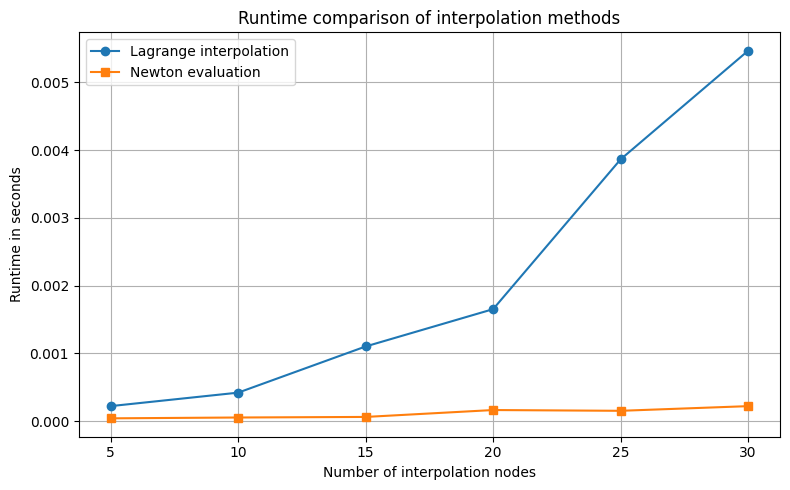

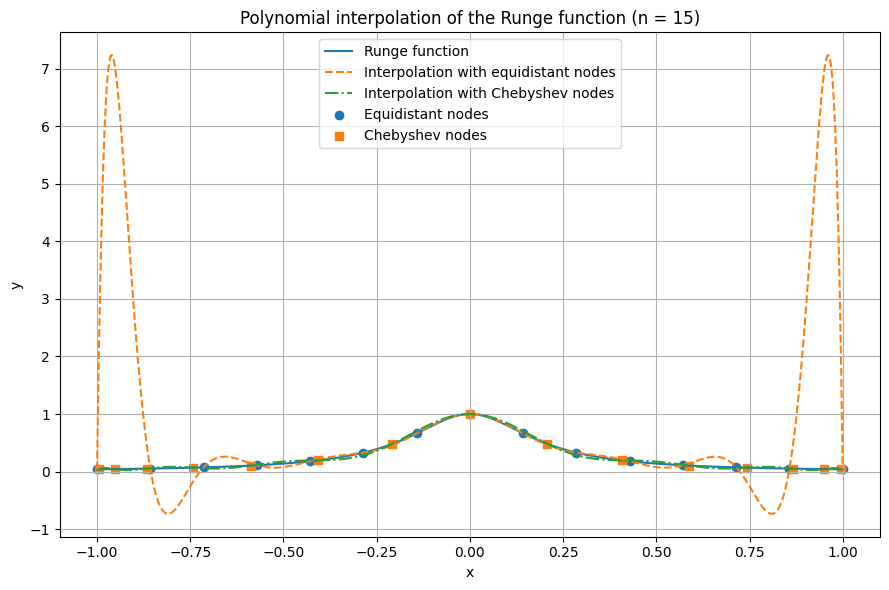

Interpolation quality comparison
n = 15
Maximum error with equidistant nodes : 7.192e+00
Maximum error with Chebyshev nodes   : 4.660e-02

Conclusion
Chebyshev nodes generally lead to a much better interpolation quality
than equidistant nodes for the Runge function.
Newton evaluation is also typically faster than direct Lagrange evaluation.
Plot saved to: polynomial_interpolation_comparison.png


In [1]:
# ================================================
# Polynomial Interpolation in Python
# Lagrange Form, Newton Form, Horner Scheme, and Node Comparison
# ================================================

import time
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# Lagrange basis and interpolation
# ------------------------------------------------
def lagrange_basis(x_nodes, j, x):
    """
    Evaluate the j-th Lagrange basis polynomial at x.
    """
    x_nodes = np.asarray(x_nodes, dtype=float)
    x = np.asarray(x, dtype=float)

    n = len(x_nodes)
    if not (0 <= j < n):
        raise IndexError("Index j out of range.")

    Lj = np.ones_like(x, dtype=float)
    xj = x_nodes[j]

    for m in range(n):
        if m != j:
            denominator = xj - x_nodes[m]
            if abs(denominator) < 1e-15:
                raise ZeroDivisionError("Duplicate interpolation nodes detected.")
            Lj *= (x - x_nodes[m]) / denominator

    return Lj


def lagrange_interpolation(x_nodes, y_nodes, x):
    """
    Evaluate the Lagrange interpolation polynomial at x.
    """
    x_nodes = np.asarray(x_nodes, dtype=float)
    y_nodes = np.asarray(y_nodes, dtype=float)
    x = np.asarray(x, dtype=float)

    if len(x_nodes) != len(y_nodes):
        raise ValueError("x_nodes and y_nodes must have the same length.")

    p = np.zeros_like(x, dtype=float)

    for j in range(len(x_nodes)):
        p += y_nodes[j] * lagrange_basis(x_nodes, j, x)

    return p


# ------------------------------------------------
# Newton interpolation
# ------------------------------------------------
def divided_differences(x_nodes, y_nodes):
    """
    Compute divided difference coefficients for Newton interpolation.
    """
    x_nodes = np.asarray(x_nodes, dtype=float)
    coeffs = np.asarray(y_nodes, dtype=float).copy()

    n = len(x_nodes)
    if len(coeffs) != n:
        raise ValueError("x_nodes and y_nodes must have the same length.")

    for j in range(1, n):
        for i in range(n - 1, j - 1, -1):
            denominator = x_nodes[i] - x_nodes[i - j]
            if abs(denominator) < 1e-15:
                raise ZeroDivisionError("Duplicate interpolation nodes detected.")
            coeffs[i] = (coeffs[i] - coeffs[i - 1]) / denominator

    return coeffs


def newton_evaluate(x_nodes, coeffs, x):
    """
    Evaluate a Newton interpolation polynomial using a Horner-like scheme.
    """
    x_nodes = np.asarray(x_nodes, dtype=float)
    coeffs = np.asarray(coeffs, dtype=float)
    x = np.asarray(x, dtype=float)

    n = len(coeffs)
    if len(x_nodes) != n:
        raise ValueError("x_nodes and coeffs must have the same length.")

    p = np.full_like(x, coeffs[-1], dtype=float)

    for k in range(n - 2, -1, -1):
        p = coeffs[k] + (x - x_nodes[k]) * p

    return p


# ------------------------------------------------
# Test function and node generation
# ------------------------------------------------
def runge_function(x):
    """
    Classical Runge function used in interpolation experiments.
    """
    x = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + 25.0 * x**2)


def equidistant_nodes(a, b, n):
    """
    Generate n equidistant interpolation nodes on [a, b].
    """
    return np.linspace(a, b, n)


def chebyshev_nodes(a, b, n):
    """
    Generate n Chebyshev nodes on [a, b].
    """
    k = np.arange(n)
    nodes = np.cos((2 * k + 1) * np.pi / (2 * n))
    return 0.5 * (a + b) + 0.5 * (b - a) * nodes[::-1]


# ------------------------------------------------
# Runtime experiment
# ------------------------------------------------
def interpolation_runtime_experiment(sizes=None, repeats=3):
    """
    Compare runtime of Lagrange interpolation and Newton evaluation.
    """
    if sizes is None:
        sizes = [5, 10, 15, 20, 25, 30]

    x_eval = np.linspace(-1.0, 1.0, 400)

    lagrange_times = []
    newton_times = []

    for n in sizes:
        x_nodes = equidistant_nodes(-1.0, 1.0, n)
        y_nodes = runge_function(x_nodes)

        # Lagrange runtime
        lagrange_runs = []
        for _ in range(repeats):
            start = time.perf_counter()
            lagrange_interpolation(x_nodes, y_nodes, x_eval)
            end = time.perf_counter()
            lagrange_runs.append(end - start)

        # Newton runtime
        coeffs = divided_differences(x_nodes, y_nodes)
        newton_runs = []
        for _ in range(repeats):
            start = time.perf_counter()
            newton_evaluate(x_nodes, coeffs, x_eval)
            end = time.perf_counter()
            newton_runs.append(end - start)

        lagrange_times.append(np.median(lagrange_runs))
        newton_times.append(np.median(newton_runs))

        print(f"Finished runtime experiment for n = {n}")

    return {
        "sizes": sizes,
        "lagrange_times": np.array(lagrange_times),
        "newton_times": np.array(newton_times),
    }


# ------------------------------------------------
# Plot runtime comparison
# ------------------------------------------------
def plot_runtime_comparison(runtime_results):
    """
    Plot runtime comparison of Lagrange and Newton interpolation.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(runtime_results["sizes"], runtime_results["lagrange_times"], "o-", label="Lagrange interpolation")
    plt.plot(runtime_results["sizes"], runtime_results["newton_times"], "s-", label="Newton evaluation")

    plt.xlabel("Number of interpolation nodes")
    plt.ylabel("Runtime in seconds")
    plt.title("Runtime comparison of interpolation methods")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# Interpolation quality experiment
# ------------------------------------------------
def compare_node_choices(n=15):
    """
    Compare polynomial interpolation using equidistant and Chebyshev nodes.
    """
    x_fine = np.linspace(-1.0, 1.0, 1000)
    y_true = runge_function(x_fine)

    x_eq = equidistant_nodes(-1.0, 1.0, n)
    y_eq = runge_function(x_eq)
    p_eq = lagrange_interpolation(x_eq, y_eq, x_fine)

    x_ch = chebyshev_nodes(-1.0, 1.0, n)
    y_ch = runge_function(x_ch)
    p_ch = lagrange_interpolation(x_ch, y_ch, x_fine)

    plt.figure(figsize=(9, 6))
    plt.plot(x_fine, y_true, label="Runge function")
    plt.plot(x_fine, p_eq, "--", label="Interpolation with equidistant nodes")
    plt.plot(x_fine, p_ch, "-.", label="Interpolation with Chebyshev nodes")
    plt.scatter(x_eq, y_eq, marker="o", label="Equidistant nodes")
    plt.scatter(x_ch, y_ch, marker="s", label="Chebyshev nodes")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Polynomial interpolation of the Runge function (n = {n})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    max_error_eq = np.max(np.abs(y_true - p_eq))
    max_error_ch = np.max(np.abs(y_true - p_ch))

    print("Interpolation quality comparison")
    print(f"n = {n}")
    print(f"Maximum error with equidistant nodes : {max_error_eq:.3e}")
    print(f"Maximum error with Chebyshev nodes   : {max_error_ch:.3e}")
    print()

    return {
        "x_fine": x_fine,
        "y_true": y_true,
        "x_eq": x_eq,
        "y_eq": y_eq,
        "p_eq": p_eq,
        "x_ch": x_ch,
        "y_ch": y_ch,
        "p_ch": p_ch,
        "max_error_eq": max_error_eq,
        "max_error_ch": max_error_ch,
    }


# ------------------------------------------------
# Save interpolation comparison plot
# ------------------------------------------------
def save_interpolation_plot(results, filename="polynomial_interpolation_comparison.png"):
    """
    Save the interpolation comparison plot to an image file.
    """
    plt.figure(figsize=(9, 6))
    plt.plot(results["x_fine"], results["y_true"], label="Runge function")
    plt.plot(results["x_fine"], results["p_eq"], "--", label="Interpolation with equidistant nodes")
    plt.plot(results["x_fine"], results["p_ch"], "-.", label="Interpolation with Chebyshev nodes")
    plt.scatter(results["x_eq"], results["y_eq"], marker="o", label="Equidistant nodes")
    plt.scatter(results["x_ch"], results["y_ch"], marker="s", label="Chebyshev nodes")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Polynomial interpolation: equidistant vs Chebyshev nodes")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Plot saved to: {filename}")


# ------------------------------------------------
# Example execution in notebook
# ------------------------------------------------
# 1) Runtime experiment
runtime_results = interpolation_runtime_experiment(
    sizes=[5, 10, 15, 20, 25, 30],
    repeats=3
)

plot_runtime_comparison(runtime_results)

# 2) Node comparison experiment
comparison_results = compare_node_choices(n=15)

print("Conclusion")
print("Chebyshev nodes generally lead to a much better interpolation quality")
print("than equidistant nodes for the Runge function.")
print("Newton evaluation is also typically faster than direct Lagrange evaluation.")

# 3) Save PNG for later download
save_interpolation_plot(
    comparison_results,
    filename="polynomial_interpolation_comparison.png"
)

## Conclusion

In this notebook several classical polynomial interpolation techniques were
implemented and compared. The Lagrange representation allows a direct
construction of the interpolation polynomial but becomes computationally
expensive when the polynomial must be evaluated many times. The Newton form,
based on divided differences, separates the preparation phase from the
evaluation phase and therefore offers a more efficient representation for
repeated evaluations.

The experiments also illustrate that computing interpolation polynomials in
the monomial basis via Vandermonde systems can be numerically problematic.
Such systems are often poorly conditioned, which may lead to numerical
instabilities for larger node sets.

A second important aspect is the choice of interpolation nodes. The comparison
between equidistant nodes and Chebyshev nodes shows that Chebyshev nodes
significantly improve stability and reduce interpolation error. This behavior
is closely related to the well-known Runge phenomenon, where equidistant nodes
lead to large oscillations near the interval boundaries.

Overall, the experiments demonstrate that successful polynomial interpolation
depends not only on the interpolation method itself but also on the numerical
representation and the selection of suitable interpolation nodes.